In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [366]:
path = "/content"
files = [
    "subscribers",
    "recharges",
    "subscriptions",
    "shop_sales",
    "complaints"
]
dfs = {
    file: pd.read_csv(os.path.join(path, f"{file}.csv"))
    for file in files
}

**Cleaning Subscribers File**

In [367]:
subscribers=dfs['subscribers']
subscribers.head()

,subscriber_id,customer_name,birth_date,governorate,region_and_zip,customer_segment,gender
0,100001,Mohamed Hassan,2/6/2006,Giza,Nasr City|11765,RED,Male
1,100002,Amr Nabil,2/26/1987,alexandria,Maadi|11431,Khatak El-Dala3,Male
2,100003,Mohamed Aly,9/8/1971,Cairo,Mohandessin|12411,Prepaid Standard,Male
3,100004,Adham El-Din,5/17/2004,cairo,Sidi Gaber|21611,Flex Control,Male
4,100005,Hossam Abdelrahman,7/28/1980,CAIRO,Mohandessin|12411,RED,Male


In [368]:
subscribers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114618 entries, 0 to 114617
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   subscriber_id     114618 non-null  int64 
 1   customer_name     114618 non-null  object
 2   birth_date        114618 non-null  object
 3   governorate       114618 non-null  object
 4   region_and_zip    114618 non-null  object
 5   customer_segment  114618 non-null  object
 6   gender            114618 non-null  object
dtypes: int64(1), object(6)
memory usage: 6.1+ MB


In [369]:
subscribers.governorate.value_counts()

,count
governorate,
Tanta,8314
giza,8314
الجيزة,8273
Alexandria,8247
CAIRO,8224
Mansoura,8210
Cairo,8169
alexandria,8168
Giza,8168


In [370]:
governorate_mapping = {
    # Cairo
    "CAIRO": "Cairo",
    "cairo": "Cairo",
    "Cairo": "Cairo",
    "القاهرة": "Cairo",

    # Giza
    "giza": "Giza",
    "Giza": "Giza",
    "الجيزة": "Giza",

    # Alexandria
    "alexandria": "Alexandria",
    "Alexandria": "Alexandria",

    # Others
    "Tanta": "Tanta",
    "Mansoura": "Mansoura",
    "Asyut": "Asyut"
}

In [371]:
subscribers['governorate']= subscribers['governorate'].map(governorate_mapping)
subscribers['governorate'].value_counts()

,count
governorate,
Cairo,32584
Giza,24688
Alexandria,16415
Tanta,8314
Mansoura,8210
Asyut,8154


In [372]:
subscribers.gender.value_counts()


,count
gender,
Male,80312
Female,34306


In [373]:
subscribers['region_and_zip']

,region_and_zip
0,Nasr City|11765
1,Maadi|11431
2,Mohandessin|12411
3,Sidi Gaber|21611
4,Mohandessin|12411
...,...
114613,Mohandessin|12411
114614,Mohandessin|12411
114615,Maadi|11431
114616,Smouha|21615


In [374]:
subscribers[['region', 'zip_code']] = subscribers['region_and_zip'].str.split('|', expand=True)

In [375]:
subscribers.head()

,subscriber_id,customer_name,birth_date,governorate,region_and_zip,customer_segment,gender,region,zip_code
0,100001,Mohamed Hassan,2/6/2006,NaN,Nasr City|11765,RED,Male,Nasr City,11765
1,100002,Amr Nabil,2/26/1987,Alexandria,Maadi|11431,Khatak El-Dala3,Male,Maadi,11431
2,100003,Mohamed Aly,9/8/1971,Cairo,Mohandessin|12411,Prepaid Standard,Male,Mohandessin,12411
3,100004,Adham El-Din,5/17/2004,Cairo,Sidi Gaber|21611,Flex Control,Male,Sidi Gaber,21611
4,100005,Hossam Abdelrahman,7/28/1980,Cairo,Mohandessin|12411,RED,Male,Mohandessin,12411


In [376]:
subscribers[['region', 'zip_code']].isnull().sum()

,0
region,0
zip_code,0


In [377]:
subscribers['region_and_zip'].str.count(r'\|').value_counts()

,count
region_and_zip,
1,114618


In [378]:
subscribers.drop(columns='region_and_zip', inplace=True)

In [379]:
subscribers.customer_segment.value_counts()

,count
customer_segment,
RED VIP,23172
Flex Control,23071
Prepaid Standard,22993
RED,22811
Khatak El-Dala3,22571


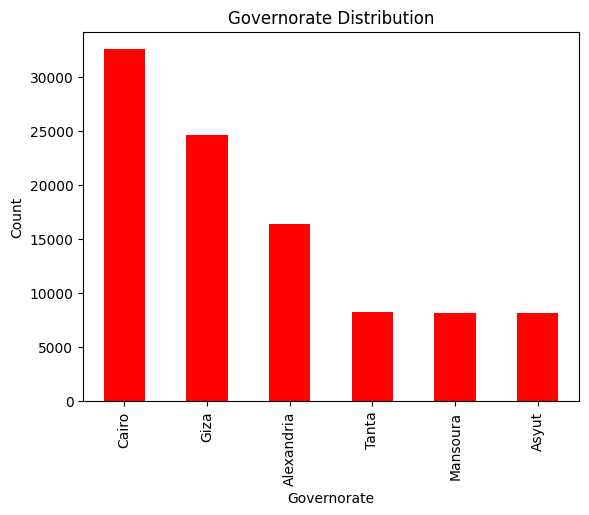

In [380]:
subscribers['governorate'].value_counts().plot(kind='bar',color='red')
plt.title('Governorate Distribution')
plt.xlabel('Governorate')
plt.ylabel('Count')
plt.show()

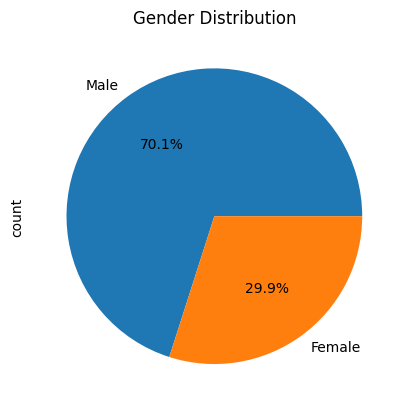

In [381]:
subscribers['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

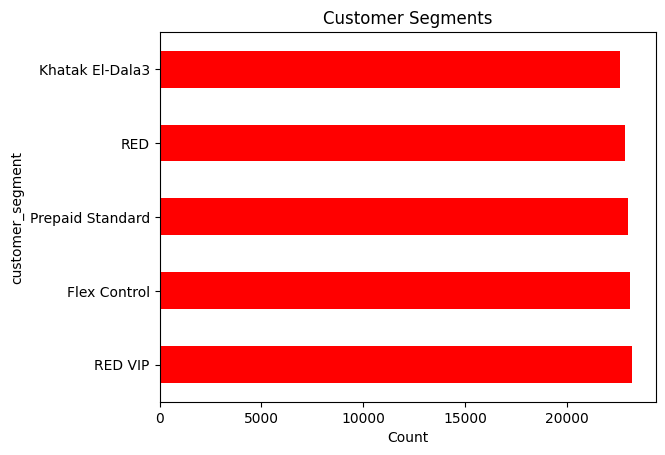

In [382]:
subscribers['customer_segment'].value_counts().plot(
    kind='barh',
    color='red'
)
plt.title("Customer Segments")
plt.xlabel("Count")
plt.show()

In [383]:
subscribers['birth_date'] = pd.to_datetime(subscribers['birth_date'])

subscribers['age'] = (
    pd.Timestamp.today().year -
    subscribers['birth_date'].dt.year
)

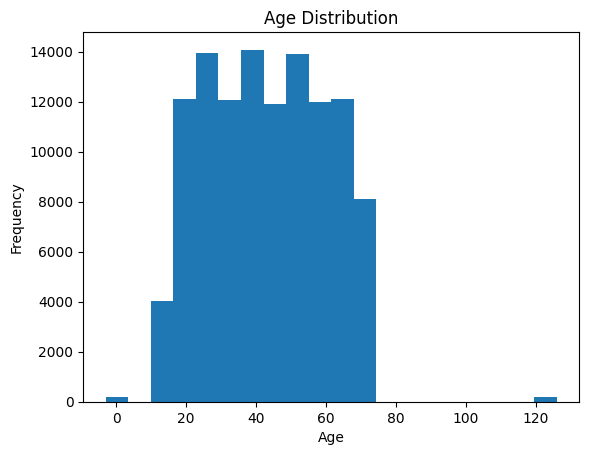

In [384]:
subscribers['age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

In [385]:
subscribers.age.describe()

,age
count,114618.000000
mean,43.080938
std,16.909790
min,-3.000000
25%,29.000000
50%,43.000000
75%,57.000000
max,126.000000


In [386]:
subscribers[(subscribers['age'] < 0) | (subscribers['age'] > 100)]

,subscriber_id,customer_name,birth_date,governorate,customer_segment,gender,region,zip_code,age
90,100091,Fatma El-Din,2029-05-05,Cairo,Khatak El-Dala3,Female,Maadi,11431,-3
184,100185,Aya Hassan,1900-01-01,NaN,RED,Female,Unknown,00000,126
570,100571,Mohamed Ibrahim,2029-05-05,Giza,RED VIP,Male,Smouha,21615,-3
612,100613,Hossam Mahmoud,2029-05-05,Giza,Flex Control,Male,Dokki,12311,-3
1388,101394,Omar Nabil,2029-05-05,NaN,Flex Control,Male,Mohandessin,12411,-3
...,...,...,...,...,...,...,...,...,...
113417,213806,Aya Hassan,2029-05-05,Cairo,RED,Female,Unknown,00000,-3
113539,213928,Ahmed Abdelrahman,2029-05-05,Cairo,Flex Control,Male,Heliopolis,11736,-3
113857,214248,Aya Abdelrahman,1900-01-01,Giza,Prepaid Standard,Female,Dokki,12311,126
114140,214532,Adham Ibrahim,1900-01-01,Cairo,Prepaid Standard,Male,Unknown,00000,126


In [387]:
subscribers[
    (subscribers['birth_date'] < '1925-01-01') |
    (subscribers['birth_date'] > pd.Timestamp.today())
]['birth_date'].value_counts()

,count
birth_date,
1900-01-01,197
2029-05-05,176


In [388]:
subscribers = subscribers[
    subscribers['age'].between(0, 100)
]

In [389]:
subscribers.head()

,subscriber_id,customer_name,birth_date,governorate,customer_segment,gender,region,zip_code,age
0,100001,Mohamed Hassan,2006-02-06,NaN,RED,Male,Nasr City,11765,20
1,100002,Amr Nabil,1987-02-26,Alexandria,Khatak El-Dala3,Male,Maadi,11431,39
2,100003,Mohamed Aly,1971-09-08,Cairo,Prepaid Standard,Male,Mohandessin,12411,55
3,100004,Adham El-Din,2004-05-17,Cairo,Flex Control,Male,Sidi Gaber,21611,22
4,100005,Hossam Abdelrahman,1980-07-28,Cairo,RED,Male,Mohandessin,12411,46


In [390]:
subscribers.isnull().sum()

,0
subscriber_id,0
customer_name,0
birth_date,0
governorate,16202
customer_segment,0
gender,0
region,0
zip_code,0
age,0


In [391]:
subscribers.groupby('region')['governorate'].value_counts(dropna=False)

region       governorate
Dokki        Cairo          3986
             Giza           3046
             Alexandria     2056
             NaN            2054
             Asyut          1053
             Mansoura       1035
             Tanta          1032
Heliopolis   Cairo          4095
             Giza           3051
             Alexandria     2022
             NaN            1957
             Tanta          1053
             Mansoura       1008
             Asyut           977
Maadi        Cairo          4068
             Giza           3095
             Alexandria     2014
             NaN            2001
             Tanta          1070
             Mansoura       1040
             Asyut          1030
Mohandessin  Cairo          4020
             Giza           3055
             NaN            2023
             Alexandria     2008
             Mansoura       1070
             Asyut          1042
             Tanta           985
Nasr City    Cairo          4040
             Giza           3067
             Alexandria     2042
             NaN            2014
             Mansoura       1003
             Asyut           990
             Tanta           980
Sidi Gaber   Cairo          4054
             Giza           3102
             Alexandria     2090
             NaN            2068
             Tanta          1052
             Mansoura       1026
             Asyut          1022
Smouha       Cairo          4038
             Giza           3162
             Alexandria     2064
             NaN            2017
             Tanta          1092
             Mansoura       1025
             Asyut          1003
Unknown      Cairo          4170
             Giza           3046
             NaN            2068
             Alexandria     2064
             Tanta          1020
             Asyut          1011
             Mansoura        969
Name: count, dtype: int64

In [392]:
subscribers['region'].value_counts(dropna=False)

,count
region,
Sidi Gaber,14414
Smouha,14401
Unknown,14348
Maadi,14318
Dokki,14262
Mohandessin,14203
Heliopolis,14163
Nasr City,14136


In [393]:
subscribers[subscribers['region'] == 'Unknown']

,subscriber_id,customer_name,birth_date,governorate,customer_segment,gender,region,zip_code,age
8,100009,Fatma Osama,2005-01-02,Alexandria,Flex Control,Female,Unknown,00000,21
12,100013,Omar Osama,1963-05-13,Alexandria,Khatak El-Dala3,Male,Unknown,00000,63
23,100024,Amr Aly,1988-10-01,Alexandria,RED,Male,Unknown,00000,38
38,100039,Sahar Nabil,1991-02-01,Asyut,RED,Female,Unknown,00000,35
41,100042,Omar Mahmoud,1969-04-18,Asyut,Prepaid Standard,Male,Unknown,00000,57
...,...,...,...,...,...,...,...,...,...
114565,214959,Ali Nabil,1963-11-10,NaN,Flex Control,Male,Unknown,00000,63
114585,214979,Hossam Ibrahim,1989-07-19,Giza,Flex Control,Male,Unknown,00000,37
114589,214983,Hossam Aly,1967-12-11,Cairo,RED VIP,Male,Unknown,00000,59
114592,214986,Aya El-Din,2006-12-18,Giza,Prepaid Standard,Female,Unknown,00000,20


In [394]:
subscribers['region'] = subscribers['region'].replace('Unknown', np.nan)

In [395]:

subscribers['zip_code'] = subscribers['zip_code'].replace('00000', np.nan)

In [396]:
subscribers[['region','zip_code']].value_counts(dropna=False)

,,count
region,zip_code,
Sidi Gaber,21611,14414
Smouha,21615,14401
NaN,NaN,14348
Maadi,11431,14318
Dokki,12311,14262
Mohandessin,12411,14203
Heliopolis,11736,14163
Nasr City,11765,14136


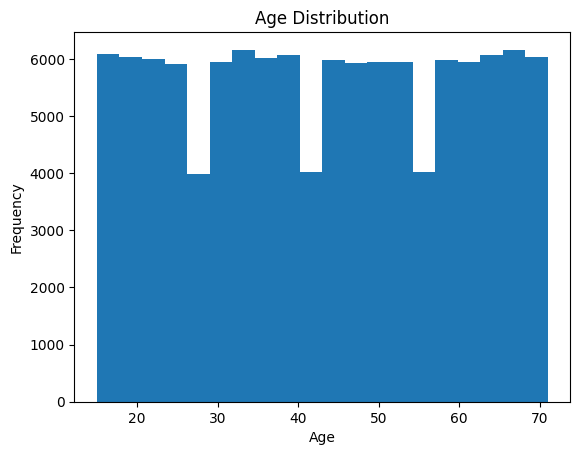

In [397]:
subscribers['age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

**Cleaning recharges File**

In [398]:
recharges = dfs['recharges']
recharges.head()

,recharge_id,subscription_id,recharge_date,amount,payment_method
0,900001,506590,1/6/2025,90,Fawry
1,900002,514096,4/6/2026,200 L.E,InstaPay
2,900003,608172,7/13/2026,20,Credit Card
3,900004,517144,11/17/2025,500,Fawry
4,900005,583108,6/5/2026,100,Fawry


In [399]:
recharges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118025 entries, 0 to 118024
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   recharge_id      118025 non-null  int64 
 1   subscription_id  118025 non-null  int64 
 2   recharge_date    118025 non-null  object
 3   amount           118025 non-null  object
 4   payment_method   118025 non-null  object
dtypes: int64(2), object(3)
memory usage: 4.5+ MB


In [400]:
recharges.payment_method.value_counts(dropna=False)

,count
payment_method,
InstaPay,29664
Credit Card,29522
Vodafone Cash,29521
Fawry,29318


In [401]:
recharges.amount.value_counts(dropna=False)

,count
amount,
90,16907
-50,13829
100,13771
500,13618
20,13602
50,13573
200,13340
EGP 200,2585
EGP 20,2574


In [402]:
recharges['amount'] = (
    recharges['amount']
    .astype(str)
    .str.replace(r'EGP\s*', '', regex=True)
    .str.replace(r'\s*L\.E', '', regex=True)
    .str.strip()
)

In [403]:
recharges['amount'] = pd.to_numeric(recharges['amount'])

In [404]:
recharges['amount'].value_counts()

,count
amount,
-50,17043
100,16958
90,16907
20,16862
500,16850
50,16740
200,16665


In [405]:
recharges['amount'] =recharges['amount'].abs()

In [406]:
recharges['amount'].value_counts()

,count
amount,
50,33783
100,16958
90,16907
20,16862
500,16850
200,16665


In [407]:
subscriptions = dfs['subscriptions']
subscriptions.head()

,subscription_id,subscriber_id,phone_number,line_type,status,activation_date
0,569927,169927,201099999795,PREPAID,Active,6/21/2024
1,522484,122484,201099993352,Postpaid,Active,10/15/2025
2,536333,136333,201099991782,Prepaid,Active,10/28/2023
3,521195,121195,201099991113,Prepaid,Active,7/16/2023
4,549917,149917,201099990489,PREPAID,Active,10/6/2025


In [408]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114994 entries, 0 to 114993
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   subscription_id  114994 non-null  int64 
 1   subscriber_id    114994 non-null  int64 
 2   phone_number     114994 non-null  int64 
 3   line_type        114994 non-null  object
 4   status           114994 non-null  object
 5   activation_date  114994 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.3+ MB


In [409]:
subscriptions.line_type.value_counts(dropna=False)

,count
line_type,
PREPAID,23185
Prepaid,23053
Hybrid,23016
postpaid,23002
Postpaid,22738


In [410]:
line_type_mapping = {
    'prepaid': 'Prepaid',
    'postpaid': 'Postpaid',
    'PREPAID': 'Prepaid',
    'Hybrid': 'Hybrid',
    'Postpaid': 'Postpaid',
    'Prepaid': 'Prepaid'
}

In [411]:
subscriptions['line_type'].unique()

array(['PREPAID', 'Postpaid', 'Prepaid ', 'Hybrid', 'postpaid'],
      dtype=object)

In [412]:
subscriptions['line_type'] = subscriptions['line_type'].str.strip()
subscriptions['line_type']=subscriptions.line_type.replace(line_type_mapping)

In [413]:
subscriptions.line_type.value_counts(dropna=False)

,count
line_type,
Prepaid,46238
Postpaid,45740
Hybrid,23016


In [414]:
subscriptions.status.value_counts(dropna=False)

,count
status,
Active,101095
Suspended,10527
Terminated,3372


In [415]:
subscriptions.phone_number.value_counts(dropna=False)

,count
phone_number,
201074747698,2
1007263237,2
201097691938,2
1014005210,2
1030469145,2
...,...
201016473705,1
201016476368,1
201016479849,1


In [416]:
subscriptions['phone_number'].duplicated().sum()

np.int64(42)

In [417]:
subscriptions[
    subscriptions['phone_number'].duplicated(keep=False)
].sort_values('phone_number')

,subscription_id,subscriber_id,phone_number,line_type,status,activation_date
113064,599323,199323,1002764857,Postpaid,Active,1/1/2025
113063,596327,196327,1002764857,Hybrid,Active,12/23/2023
111162,560595,160595,1005631373,Postpaid,Active,7/11/2022
111161,558269,158269,1005631373,Hybrid,Suspended,1/28/2021
110021,550935,150935,1007263237,Postpaid,Active,9/6/2018
...,...,...,...,...,...,...
4005,536547,136547,201091040691,Prepaid,Active,7/16/2020
3409,577142,177142,201092389279,Prepaid,Active,5/7/2019
3410,606389,206389,201092389279,Hybrid,Active,11/22/2022
1020,584965,184965,201097691938,Hybrid,Active,12/5/2024


In [418]:
subscriptions['phone_number'] = subscriptions['phone_number'].astype(str)

subscriptions['phone_number'].str.len().value_counts()

,count
phone_number,
10,69085
12,45909


In [419]:

subscriptions['phone_number'] = subscriptions['phone_number'].apply(
    lambda x: '20' + x if len(x) == 10 else x
)

In [420]:
subscriptions

,subscription_id,subscriber_id,phone_number,line_type,status,activation_date
0,569927,169927,201099999795,Prepaid,Active,6/21/2024
1,522484,122484,201099993352,Postpaid,Active,10/15/2025
2,536333,136333,201099991782,Prepaid,Active,10/28/2023
3,521195,121195,201099991113,Prepaid,Active,7/16/2023
4,549917,149917,201099990489,Prepaid,Active,10/6/2025
...,...,...,...,...,...,...
114989,568365,168365,201000003847,Prepaid,Active,1/2/2025
114990,587733,187733,201000002144,Postpaid,Terminated,7/6/2025
114991,603202,203202,201000002058,Postpaid,Active,3/24/2022
114992,506590,106590,201000001480,Postpaid,Active,7/3/2021


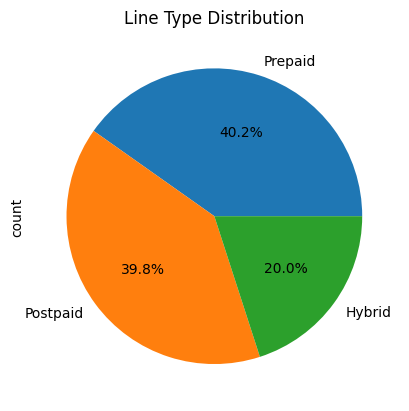

In [421]:
subscriptions['line_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Line Type Distribution")
plt.show()

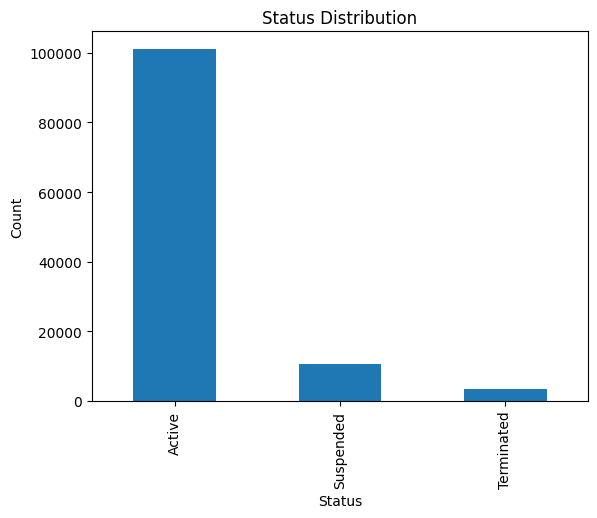

In [422]:
subscriptions['status'].value_counts().plot(kind='bar')
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Status Distribution")
plt.show()

# **Cleaning shop_sales File**

In [423]:
shop_sales = dfs['shop_sales']
shop_sales.head()

,sales_id,subscriber_id,transaction_date,product_name,quantity,total_sales_amount,store_branch
0,200001,186497,2/8/2026,Vodafone VR Glasses,1,350,Online Shop
1,200002,101547,4/12/2026,Mi Fi Router,1,600,Alexandria Port Said St
2,200003,137251,6/12/2026,Mi Fi Router,1,600,City Stars Branch
3,200004,132950,5/6/2026,Vodafone VR Glasses,1,350,Online Shop
4,200005,129630,3/3/2026,iPhone 15 Pro,1,55000,Online Shop


In [424]:
shop_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113904 entries, 0 to 113903
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   sales_id            113904 non-null  int64 
 1   subscriber_id       113904 non-null  int64 
 2   transaction_date    113904 non-null  object
 3   product_name        113904 non-null  object
 4   quantity            113904 non-null  int64 
 5   total_sales_amount  113904 non-null  object
 6   store_branch        113904 non-null  object
dtypes: int64(3), object(4)
memory usage: 6.1+ MB


In [425]:
shop_sales.store_branch.value_counts(dropna=False)

,count
store_branch,
City Stars Branch,28670
Online Shop,28537
Zamalek Branch,28379
Alexandria Port Said St,28318


In [426]:
shop_sales.product_name.value_counts(dropna=False)

,count
product_name,
iPhone 15 Pro,28614
Vodafone VR Glasses,28596
Mi Fi Router,28427
Samsung Galaxy A15,28267


In [427]:
shop_sales.describe()

,sales_id,subscriber_id,quantity
count,113904.000000,113904.000000,113904.000000
mean,257498.983653,157425.829102,1.161452
std,33186.160386,33111.127908,0.443114
min,200001.000000,100001.000000,1.000000
25%,228761.750000,128811.750000,1.000000
50%,257498.500000,157420.000000,1.000000
75%,286229.250000,186058.000000,1.000000
max,315000.000000,215000.000000,3.000000


In [428]:
shop_sales['total_sales_amount'].value_counts(dropna=False)

,count
total_sales_amount,
350,27188
55000,27178
600,27041
7500,26829
FREE,5668


In [429]:
shop_sales[shop_sales['total_sales_amount'] == 'FREE']['product_name'].value_counts()

,count
product_name,
Samsung Galaxy A15,1438
iPhone 15 Pro,1436
Vodafone VR Glasses,1408
Mi Fi Router,1386


In [430]:
shop_sales['total_sales_amount'] = shop_sales['total_sales_amount'].replace('FREE', 0)
shop_sales['total_sales_amount'] = pd.to_numeric(
    shop_sales['total_sales_amount']
)

In [431]:
shop_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113904 entries, 0 to 113903
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   sales_id            113904 non-null  int64 
 1   subscriber_id       113904 non-null  int64 
 2   transaction_date    113904 non-null  object
 3   product_name        113904 non-null  object
 4   quantity            113904 non-null  int64 
 5   total_sales_amount  113904 non-null  int64 
 6   store_branch        113904 non-null  object
dtypes: int64(4), object(3)
memory usage: 6.1+ MB


# **Cleaning complaints File**

In [432]:
complaints = dfs['complaints']
complaints.head()

,complaint_id,subscriber_id,complaint_date,category,resolution_days,satisfaction_score
0,800001,102769,2026-01-08,NETWORK,2,NaN
1,800002,137307,2026-03-25,Internet Speed,1,2.0
2,800003,135026,2026-01-03,Network Issue,1,3.0
3,800004,114954,2026-04-18,Internet Speed,2,NaN
4,800005,191854,2026-01-14,Internet Speed,1,NaN


In [433]:
complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   complaint_id        105000 non-null  int64  
 1   subscriber_id       105000 non-null  int64  
 2   complaint_date      105000 non-null  object 
 3   category            105000 non-null  object 
 4   resolution_days     96558 non-null   object 
 5   satisfaction_score  87642 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 4.8+ MB


In [434]:
complaints.category.value_counts(dropna=False)

,count
category,
NETWORK,26451
billing,26240
Internet Speed,26183
Network Issue,26126


In [435]:
complaints['category'] = complaints['category'].str.strip().replace({'NETWORK':'Network Issue'})

In [436]:
complaints.category.value_counts(dropna=False)

,count
category,
Network Issue,52577
billing,26240
Internet Speed,26183


In [437]:
complaints.resolution_days.value_counts(dropna=False)

,count
resolution_days,
1,42061
2,31537
5,10479
3,10448
NaN,8442
blank,2033


In [438]:
complaints['resolution_days'] = complaints['resolution_days'].replace('blank', np.nan)
complaints['resolution_days'] = pd.to_numeric(
    complaints['resolution_days'],
    errors='coerce'
)

In [439]:
complaints.resolution_days.value_counts(dropna=False)

,count
resolution_days,
1.0,42061
2.0,31537
5.0,10479
NaN,10475
3.0,10448


In [440]:
complaints.satisfaction_score.value_counts(dropna=False)


,count
satisfaction_score,
3.0,17713
5.0,17589
2.0,17507
4.0,17506
NaN,17358
1.0,17327


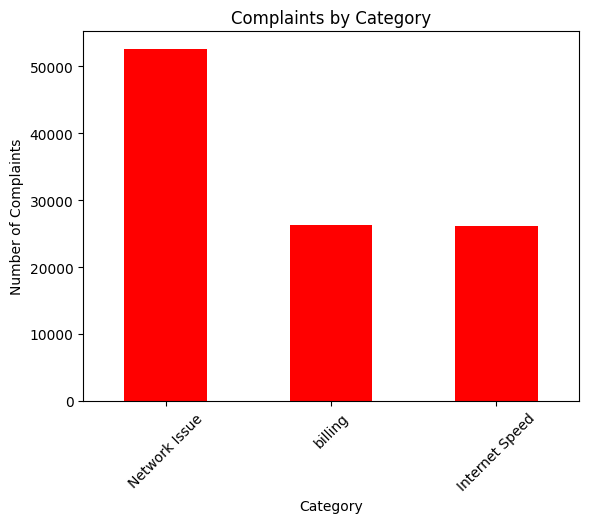

In [441]:
complaints['category'].value_counts().plot(
    kind='bar',
    color='red'
)
plt.title("Complaints by Category")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

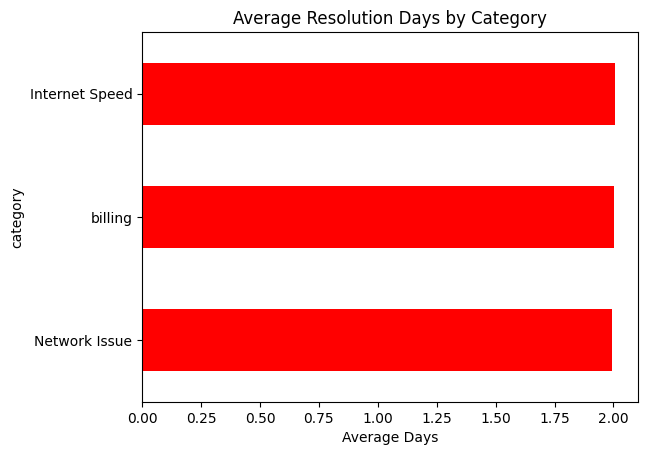

In [442]:
complaints.groupby('category')['resolution_days'].mean().sort_values().plot(
    kind='barh',
    color='red'
)
plt.title("Average Resolution Days by Category")
plt.xlabel("Average Days")
plt.show()

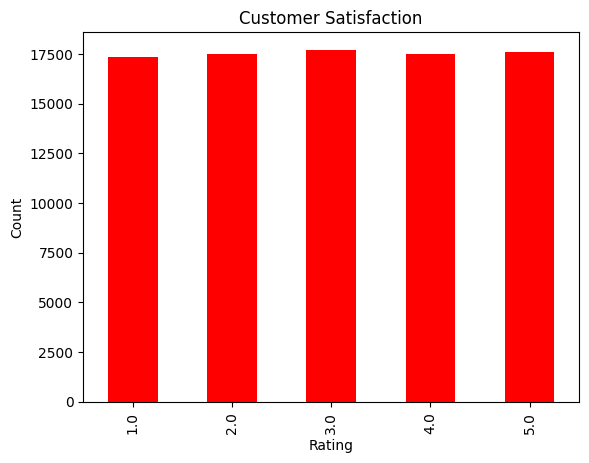

In [443]:
complaints['satisfaction_score'].value_counts().sort_index().plot(
    kind='bar' ,
    color='red'
)

plt.title("Customer Satisfaction")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [444]:

output_path = "/content/clean_data"
os.makedirs(output_path, exist_ok=True)

subscribers.to_csv(f"{output_path}/subscribers_clean.csv", index=False)
recharges.to_csv(f"{output_path}/recharges_clean.csv", index=False)
subscriptions.to_csv(f"{output_path}/subscriptions_clean.csv", index=False)
shop_sales.to_csv(f"{output_path}/shop_sales_clean.csv", index=False)
complaints.to_csv(f"{output_path}/complaints_clean.csv", index=False)

In [446]:
from google.colab import files

files.download('/content/clean_data/subscribers_clean.csv')
files.download('/content/clean_data/recharges_clean.csv')
files.download('/content/clean_data/subscriptions_clean.csv')
files.download('/content/clean_data/shop_sales_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [447]:
files.download('/content/clean_data/complaints_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>